In [1]:
# import dependencies
%matplotlib inline
import os
import sys
import spatioev as se
import scanpy as sc
import pandas as pd

# Import Scimap
import scimap as sm

from spatioev.config import ClusteringConfig

Running SCIMAP  2.3.5


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/mpl_scatter_density/__init__.py:4: UserWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
# set a working directory
wdir = ('/Users/shihongwu/SpatioEv')
os.chdir(wdir)

In [3]:
adata = se.load_h5ad("data/exp_1.h5ad")
adata

AnnData object with n_obs × n_vars = 51932 × 25
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractal_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11c_nuclear', 'CD14_nuclear', 'CD146_nuclear', 'CD19_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD4_nuclear', 'CD45_nuclear', 'CD68_nuclear', 'CD90_nuclear', 'CK19_nuclear', 'COL1A1_nuclear', 'COL4A1_nuclear', 'COL6A1_nuclear', 'FN_nuclear', 'HLADR_nuclear', 'IGFBP5_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDPN_nuclear', 'RS6_nuclear', 'SMA_nuclear', 'Tenascin_nuclear', 'Vimentin_nuclear', 'dapi_nuclear', 'label_nuclear', 'area_nuclear', 'eccentricity_nuclear', 'major_axis_length_nuclear', 'min

In [4]:
# 1) Read annotations CSV (saved from adata_final.obs.to_csv, so index is first column)
ann = pd.read_csv("results/svm_phenotyping_results.csv", index_col=0)

# 2) Optional: keep only columns you want
ann = ann[["annotated_clusters_update3", "svm_prediction"]]

# 3) Join into adata.obs by cell ID (index)
adata.obs = adata.obs.join(ann, how="left")

In [5]:
adata = se.compute_local_density_by_phenotype(
    adata,
    phenotype_key="annotated_clusters_update3",
    k_neighbors=5
)

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'Density map: exp | CD4 T cells'}, xlabel='X centroid', ylabel='Y centroid'>)

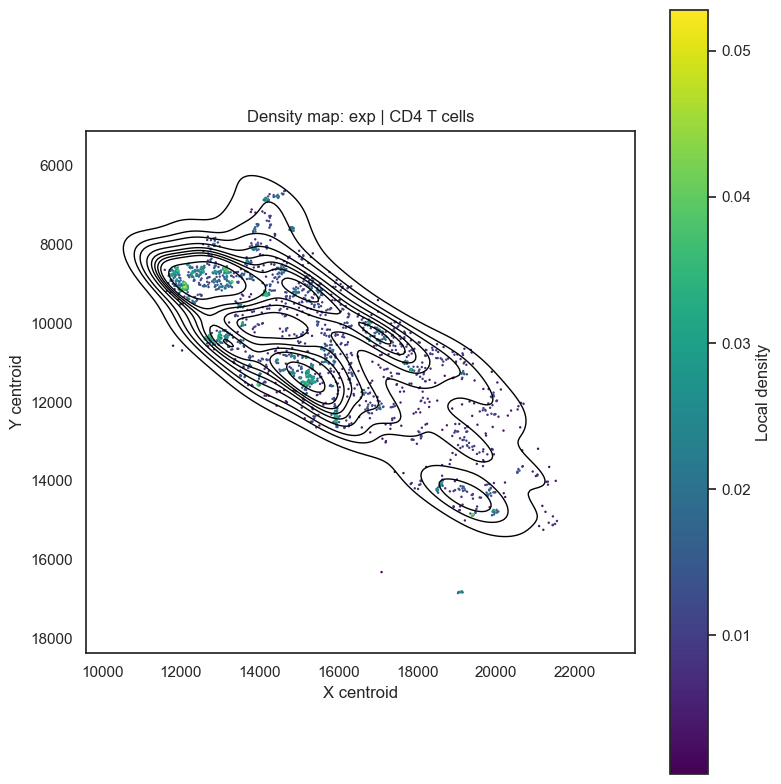

In [6]:
se.plot_local_density_map(
    adata,
    image_id="exp",
    phenotype_key="annotated_clusters_update3",
    phenotype="CD4 T cells",
    density_key="density_pheno"
)

In [7]:
adata = se.compute_local_density_all_cells(
    adata,
    k_neighbors=5
)

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'Density map: exp'}, xlabel='X centroid', ylabel='Y centroid'>)

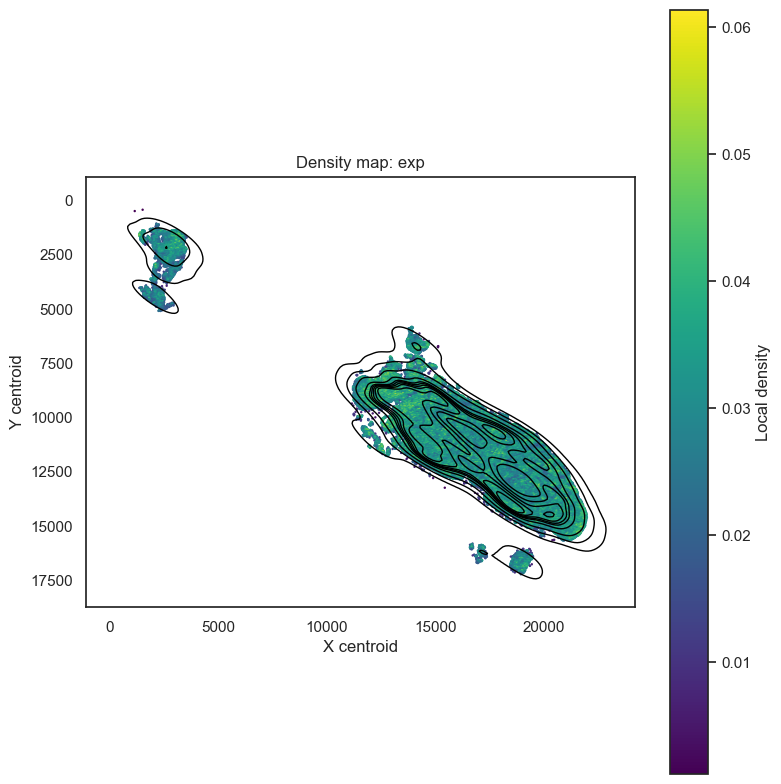

In [8]:
se.plot_local_density_map(
    adata,
    image_id="exp",
    phenotype_key="annotated_clusters_update3",
    density_key="density_all"
)